In [1]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
import pywt

In [3]:
with open('../data/moving_lfp.pickle', 'rb') as f:
    data = pickle.load(f)

lfp = np.array(data['lfp'])
fs  = data['sampling_rate']

# grab 4 seconds
t0, t1 = 10, 14
s0, s1 = int(t0 * fs), int(t1 * fs)
signal = lfp[s0:s1]
t      = np.arange(len(signal)) / fs

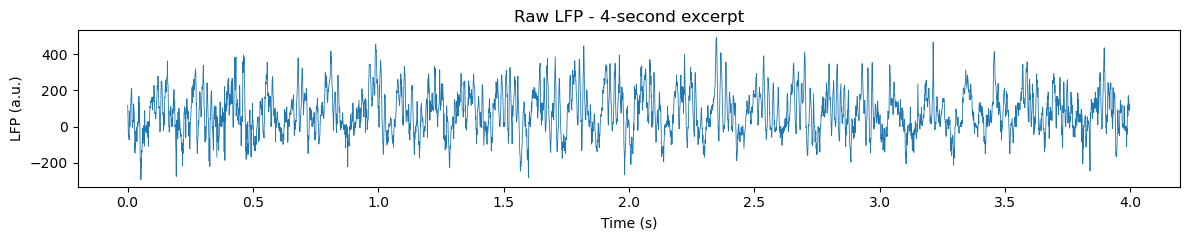

In [6]:
plt.figure(figsize=(12, 2.5))
plt.plot(t, signal, lw=0.6)
plt.xlabel('Time (s)')
plt.ylabel('LFP (a.u.)')
plt.title('Raw LFP - 4-second excerpt')
plt.tight_layout()
plt.show()

## CWT with real wavelets

In [ ]:
# scales --> approximate frequency axis (centre freq / scale / dt)
scales = np.geomspace(2, 200, 100)

real_wavelets = ['mexh', 'gaus4', 'morl']
labels        = ['Mexican Hat (mexh)', 'Gaussian (gaus4)', 'Morlet real (morl)']

fig, axes = plt.subplots(len(real_wavelets), 1, figsize=(13, 10), sharex=True)

for ax, wname, label in zip(axes, real_wavelets, labels):
    coef, freqs = pywt.cwt(signal, scales, wname, sampling_period=1/fs)
    power = np.abs(coef) ** 2
    ax.pcolormesh(t, freqs, power, shading='gouraud', cmap='inferno')
    ax.set_ylabel('Freq (Hz)')
    ax.set_ylim(1, 100)
    ax.set_title(label)
axes[-1].set_xlabel('Time (s)')
plt.suptitle('CWT Power - Real Wavelets', y=1.01)
plt.tight_layout()
plt.show()

## CWT with complex Morlet

In [ ]:
coef_cmor, freqs_cmor = pywt.cwt(signal, scales, 'cmor1.5-1.0', sampling_period=1/fs)
power_cmor = np.abs(coef_cmor) ** 2
plt.figure(figsize=(13, 3.5))
plt.pcolormesh(t, freqs_cmor, power_cmor, shading='gouraud', cmap='inferno')
plt.colorbar(label='Power')
plt.ylabel('Freq (Hz)')
plt.xlabel('Time (s)')
plt.ylim(1, 100)
plt.title('CWT Power — Complex Morlet (cmor)')
plt.tight_layout()
plt.show()

## Side by side comparison

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True, sharey=True)
wavelet_list = [('mexh', 'Mexican Hat'), ('gaus4', 'Gaussian'), ('morl', 'Morlet (real)'), ('cmor1.5-1.0', 'Complex Morlet')]

for ax, (wname, label) in zip(axes.flat, wavelet_list):
    coef, freqs = pywt.cwt(signal, scales, wname, sampling_period=1/fs)
    ax.pcolormesh(t, freqs, np.abs(coef)**2, shading='gouraud', cmap='inferno')
    ax.set_title(label)
    ax.set_ylim(1, 100)
    ax.set_ylabel('Freq (Hz)')
    ax.set_xlabel('Time (s)')

plt.suptitle('Real vs Complex Wavelet CWT Comparison', fontsize=13)

plt.tight_layout()

plt.show()

## Discussion
**Real and Complex Wavelets in the CWT**
Real wavelets (Mexican hat, Gaussian derivatives, real Morlet) are symmetric or antisymmetric functions.  
Since they have no imaginary part, the transform coefficients oscillate in sign as the wavelet sweeps over the signal: the power calculated as |coef|^2 still shows these oscillations as **amplitude modulations** superimposed on the spectrogram. The result is a striped and “wavy” time-frequency map whose peaks alternate with troughs at intervals of about half a period.
The **complex Morlet** (a complex sine wave with a Gaussian window) has both a real and an imaginary part that are 90° out of phase (cosine + i x sine). Taking the modulus |coef| = sqrt(Re^2 + Im^2) cancels out the oscillatory interference and yields a **smooth, slowly varying envelope**. This is the analytical signal approach: the imaginary part acts as the Hilbert complement of the real part, so the modulus traces the instantaneous amplitude without the half-cycle undulation.
Practical implications:
- Real wavelets blur transient events in time because the sign alternations make it difficult to pinpoint *when* the energy arrives.
- The complex Morlet wavelet provides a much clearer picture of when a frequency band is active, which is why it (and the corresponding Morlet-based spectrogram) is the standard tool for time-frequency analysis of neural signals such as LFPs.

